# Facial-Expression Image Classifier — "Depressive" vs "Neutral"
### A CNN built from scratch (PyTorch) — step by step

**Dataset:** `gudiyasingh/emotion-dataset-for-mental-health` (Kaggle) — 48×48 grayscale facial images relabeled into two classes: `Depressive` and `Neutral`.

> ⚠️ **Important scope note.** This dataset is a *relabeled facial-expression* set (it is derived from the classic FER-style emotion images), not clinically-diagnosed depression data. A CNN trained on it learns to recognize an expression pattern the dataset creator labeled "depressive," **not** to diagnose depression. Facial expression alone is not a validated clinical marker of depression. Treat every output of this notebook as an *emotion-image classification demo*, not a diagnostic tool, and say so wherever results are reported (slides included).

**What this notebook does, in order:**
1. Download & inspect the dataset
2. Preprocessing & data pipeline
3. Build a CNN architecture from scratch
4. Walk through **forward propagation** manually (shapes at every layer)
5. Walk through **backward propagation** manually (loss → gradients → weight update)
6. Full training loop with logged settings
7. Evaluation: accuracy, precision/recall/F1, confusion matrix, curves
8. Upload-your-own-image inference widget


## 1. Environment setup

In [1]:
# Core libraries
import os, random, time, copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Download the dataset

Uses `kagglehub` exactly as provided. Run this in an environment with internet access
(Kaggle Notebooks / Colab / local machine with Kaggle API credentials configured).

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gudiyasingh/emotion-dataset-for-mental-health")
print("Path to dataset files:", path)


100%|██████████| 36.3M/36.3M [00:00<00:00, 66.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gudiyasingh/emotion-dataset-for-mental-health/versions/1


In [3]:
# Inspect the folder structure that kagglehub downloaded
for root, dirs, files in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth >= 2:
        print(f"{indent}  ... {len(files)} files")


1/
  images/
    train/
      ... 0 files
      depressive/
        ... 3229 files
      natural/
        ... 3838 files
    validation/
      ... 0 files
      depressive/
        ... 3229 files
      natural/
        ... 3838 files
    test/
      ... 0 files
      depressive/
        ... 3229 files
      natural/
        ... 3838 files


In [8]:
TRAIN_DIR = os.path.join(path, "images", "train")
VAL_DIR   = os.path.join(path, "images", "validation")
TEST_DIR  = os.path.join(path, "images", "test")

for split_name, split_dir in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    if os.path.isdir(split_dir):
        for cls in sorted(os.listdir(split_dir)):
            cls_path = os.path.join(split_dir, cls)
            if os.path.isdir(cls_path):
                print(f"{split_name:12s} | {cls:12s} | {len(os.listdir(cls_path))} images)")

Train        | depressive   | 3229 images)
Train        | natural      | 3838 images)
Validation   | depressive   | 3229 images)
Validation   | natural      | 3838 images)
Test         | depressive   | 3229 images)
Test         | natural      | 3838 images)


## 3. Dataset description (for the slides / report)

| Property | Value |
|---|---|
| Task | Binary image classification |
| Classes | `Depressive`, `Neutral` |
| Image size | 48 × 48 |
| Color mode | Grayscale (1 channel) |
| Format | PNG/JPG |
| Split | Train / Validation / Test (provided by the dataset author) |
| License | CC0: Public Domain |

Run the cell below to visualize a few samples from each class.

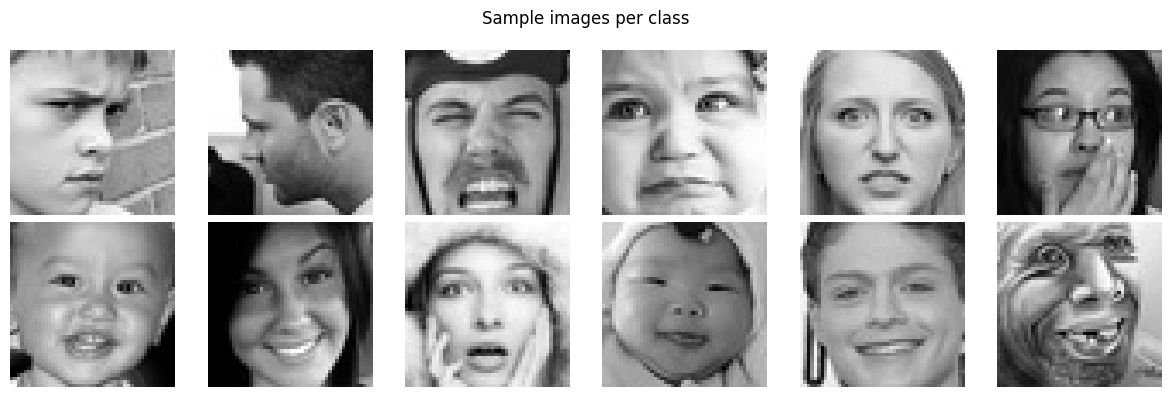

In [9]:
def show_samples(directory, n=6):
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    fig, axes = plt.subplots(len(classes), n, figsize=(2*n, 2*len(classes)))
    for row, cls in enumerate(classes):
        cls_dir = os.path.join(directory, cls)
        files = os.listdir(cls_dir)[:n]
        for col, f in enumerate(files):
            img = plt.imread(os.path.join(cls_dir, f))
            ax = axes[row, col] if len(classes) > 1 else axes[col]
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(cls)
    plt.suptitle("Sample images per class")
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR)


## 4. Preprocessing & data pipeline

Steps applied to every image:
1. **Grayscale** (images already are, but we force 1 channel for safety)
2. **Resize** to 48×48 (native size — kept, no upsampling needed)
3. **Data augmentation** (train split only) — small random rotation + horizontal flip, to reduce overfitting on a modestly-sized dataset
4. **ToTensor** — scales pixel values from [0, 255] to [0.0, 1.0]
5. **Normalize** with the dataset's own mean/std (computed below) so pixel values are roughly zero-centered — this speeds up and stabilizes gradient-based training


In [10]:
# First pass with a plain ToTensor transform, just to compute mean/std
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

_tmp_train = datasets.ImageFolder(TRAIN_DIR, transform=basic_transform)
_tmp_loader = DataLoader(_tmp_train, batch_size=256, shuffle=False, num_workers=0)

mean = 0.0
std = 0.0
n_samples = 0
for imgs, _ in _tmp_loader:
    b = imgs.size(0)
    imgs = imgs.view(b, -1)
    mean += imgs.mean(1).sum()
    std  += imgs.std(1).sum()
    n_samples += b
mean /= n_samples
std  /= n_samples
print(f"Computed dataset mean={mean:.4f}, std={std:.4f}")


Computed dataset mean=0.5057, std=0.2128


In [11]:
# Final transforms used for training / evaluation
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean.item()], std=[std.item()]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean.item()], std=[std.item()]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

CLASS_NAMES = train_ds.classes
print("Classes (index -> name):", train_ds.class_to_idx)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Classes (index -> name): {'depressive': 0, 'natural': 1}
Train: 7067 | Val: 7067 | Test: 7067


## 5. CNN architecture — built from scratch

Design rationale for a 48×48 grayscale, 2-class problem:
- 3 convolutional blocks (Conv → BatchNorm → ReLU → MaxPool), doubling channels each block (32 → 64 → 128) while halving spatial size (48 → 24 → 12 → 6)
- Dropout before the fully-connected layers to fight overfitting on a small dataset
- Two FC layers ending in 2 logits (fed to CrossEntropyLoss, which applies log-softmax internally)

```
Input  (1, 48, 48)
  │
  ├─ Conv2d(1→32, k3, pad1) → BatchNorm2d(32) → ReLU → MaxPool2d(2)     → (32, 24, 24)
  ├─ Conv2d(32→64, k3, pad1) → BatchNorm2d(64) → ReLU → MaxPool2d(2)    → (64, 12, 12)
  ├─ Conv2d(64→128, k3, pad1) → BatchNorm2d(128) → ReLU → MaxPool2d(2)  → (128, 6, 6)
  │
  ├─ Flatten                                                            → (4608,)
  ├─ Dropout(0.4)
  ├─ Linear(4608 → 256) → ReLU → Dropout(0.3)
  └─ Linear(256 → 2)                                                    → logits
```
A rendered block diagram of this exact architecture is included in the slide deck.


In [12]:
class EmotionCNN(nn.Module):
    """Custom CNN for 48x48 grayscale, 2-class emotion image classification."""
    def __init__(self, num_classes=2, dropout1=0.4, dropout2=0.3):
        super().__init__()

        # ---- Feature extractor: 3 conv blocks ----
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 48 -> 24
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 24 -> 12
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 12 -> 6
        )

        # ---- Classifier head ----
        self.flatten = nn.Flatten()
        self.drop1 = nn.Dropout(dropout1)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.relu_fc = nn.ReLU(inplace=True)
        self.drop2 = nn.Dropout(dropout2)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.drop1(x)
        x = self.relu_fc(self.fc1(x))
        x = self.drop2(x)
        x = self.fc2(x)          # raw logits; CrossEntropyLoss applies softmax internally
        return x

model = EmotionCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")


EmotionCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (drop1): Dropout(p=0.4, inp

## 6. Forward propagation — step by step, with real tensor shapes

This cell pushes **one real batch** through the network layer-by-layer (instead of calling
`model(x)` as one black box) so every intermediate shape and operation is visible:

- **Convolution**: each filter slides over the input computing a weighted sum + bias — this is
  the dot product between the filter weights and the local receptive field, repeated at every
  spatial position, producing a feature map.
- **BatchNorm**: normalizes each channel's activations across the batch (zero mean, unit
  variance), then applies a learned scale/shift — stabilizes and speeds up training.
- **ReLU**: `max(0, x)` — introduces non-linearity so the stacked convolutions can approximate
  non-linear decision boundaries, not just linear ones.
- **MaxPool**: takes the max value in each 2×2 window, halving height and width — keeps the
  strongest activation, discards spatial redundancy, and reduces computation.
- **Flatten + Linear + Linear**: turns the final feature map into a flat vector, then two fully
  connected layers combine those features into 2 class logits.


In [13]:
model.eval()
sample_imgs, sample_labels = next(iter(train_loader))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    x = sample_imgs
    print("Input                 :", tuple(x.shape))

    x = model.block1(x)
    print("After block1 (conv+pool):", tuple(x.shape))

    x = model.block2(x)
    print("After block2 (conv+pool):", tuple(x.shape))

    x = model.block3(x)
    print("After block3 (conv+pool):", tuple(x.shape))

    x = model.flatten(x)
    print("After flatten           :", tuple(x.shape))

    x = model.drop1(x)
    x = model.relu_fc(model.fc1(x))
    print("After fc1 + ReLU        :", tuple(x.shape))

    x = model.drop2(x)
    logits = model.fc2(x)
    print("Output logits           :", tuple(logits.shape))

    probs = F.softmax(logits, dim=1)
    print("\nExample softmax probabilities for first 3 images in the batch:")
    for i in range(3):
        print(f"  image {i}: {dict(zip(CLASS_NAMES, [round(p, 3) for p in probs[i].tolist()]))}")


Input                 : (64, 1, 48, 48)
After block1 (conv+pool): (64, 32, 24, 24)
After block2 (conv+pool): (64, 64, 12, 12)
After block3 (conv+pool): (64, 128, 6, 6)
After flatten           : (64, 4608)
After fc1 + ReLU        : (64, 256)
Output logits           : (64, 2)

Example softmax probabilities for first 3 images in the batch:
  image 0: {'depressive': 0.504, 'natural': 0.496}
  image 1: {'depressive': 0.495, 'natural': 0.505}
  image 2: {'depressive': 0.492, 'natural': 0.508}


## 7. Backward propagation — step by step

Backward propagation is how the network learns: it computes **how much each weight
contributed to the error**, then nudges every weight a small step in the direction that
reduces that error.

1. **Forward pass** — compute logits, then the loss (`CrossEntropyLoss`, which combines
   log-softmax + negative log-likelihood).
2. **`optimizer.zero_grad()`** — clear old gradients (PyTorch accumulates them otherwise).
3. **`loss.backward()`** — PyTorch's autograd walks the computation graph *backwards* from the
   loss to every parameter, applying the chain rule at each layer
   (`∂loss/∂W = ∂loss/∂output × ∂output/∂W`) to compute the gradient of the loss with respect
   to every weight and bias in the network.
4. **`optimizer.step()`** — updates each parameter: `W ← W − learning_rate × ∂loss/∂W`
   (Adam adapts this update per-parameter using running estimates of the gradient's mean and
   variance).

The cell below runs exactly one such step manually and prints the gradient norm of a layer
from each stage of the network, so you can see gradients actually flowing from the output
layer back to the first convolution.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
sample_imgs, sample_labels = sample_imgs.to(device), sample_labels.to(device)

# 1. Forward pass
logits = model(sample_imgs)
loss = criterion(logits, sample_labels)
print(f"Loss before this step: {loss.item():.4f}")

# 2. Clear old gradients
optimizer.zero_grad()

# 3. Backward pass: autograd computes d(loss)/d(every parameter)
loss.backward()

print("\nGradient norms (evidence that error is flowing all the way back to layer 1):")
print(f"  fc2.weight    (output layer)   : {model.fc2.weight.grad.norm():.6f}")
print(f"  fc1.weight    (hidden layer)   : {model.fc1.weight.grad.norm():.6f}")
print(f"  block3 conv.weight (deep conv) : {model.block3[0].weight.grad.norm():.6f}")
print(f"  block1 conv.weight (first conv): {model.block1[0].weight.grad.norm():.6f}")

# 4. Update every weight: W <- W - lr * grad  (Adam's adaptive version of this rule)
optimizer.step()

with torch.no_grad():
    new_loss = criterion(model(sample_imgs), sample_labels)
print(f"\nLoss after this single update step: {new_loss.item():.4f}")


Loss before this step: 0.7423

Gradient norms (evidence that error is flowing all the way back to layer 1):
  fc2.weight    (output layer)   : 1.197909
  fc1.weight    (hidden layer)   : 4.845356
  block3 conv.weight (deep conv) : 1.311912
  block1 conv.weight (first conv): 0.323614

Loss after this single update step: 2.6395


## 8. Full training loop

**Training settings used:**

| Setting | Value |
|---|---|
| Optimizer | Adam |
| Learning rate | 1e-3 (with ReduceLROnPlateau on validation loss) |
| Loss function | CrossEntropyLoss |
| Batch size | 64 |
| Epochs | 30 (early-stopped on best validation loss) |
| Regularization | BatchNorm + Dropout(0.4, 0.3) + light data augmentation |


In [15]:
# Re-initialize a fresh model/optimizer for the real training run
model = EmotionCNN(num_classes=len(CLASS_NAMES)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

EPOCHS = 30
best_val_loss = float("inf")
best_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total, correct / total

start = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);   history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

print(f"\nTraining finished in {(time.time()-start)/60:.1f} min. Best val_loss={best_val_loss:.4f}")
model.load_state_dict(best_state)  # restore best checkpoint


Epoch  1/30 | train_loss=0.7161 train_acc=0.5752 | val_loss=0.6633 val_acc=0.6117
Epoch  2/30 | train_loss=0.6678 train_acc=0.5932 | val_loss=0.6501 val_acc=0.6160
Epoch  3/30 | train_loss=0.6540 train_acc=0.6100 | val_loss=0.6263 val_acc=0.6424
Epoch  4/30 | train_loss=0.6389 train_acc=0.6249 | val_loss=0.5998 val_acc=0.6632
Epoch  5/30 | train_loss=0.6177 train_acc=0.6501 | val_loss=0.5798 val_acc=0.6905
Epoch  6/30 | train_loss=0.6017 train_acc=0.6713 | val_loss=0.5645 val_acc=0.6994
Epoch  7/30 | train_loss=0.5876 train_acc=0.6753 | val_loss=0.5440 val_acc=0.7106
Epoch  8/30 | train_loss=0.5816 train_acc=0.6856 | val_loss=0.5380 val_acc=0.7272
Epoch  9/30 | train_loss=0.5696 train_acc=0.6973 | val_loss=0.5218 val_acc=0.7344
Epoch 10/30 | train_loss=0.5576 train_acc=0.7103 | val_loss=0.5165 val_acc=0.7320
Epoch 11/30 | train_loss=0.5456 train_acc=0.7190 | val_loss=0.4876 val_acc=0.7563
Epoch 12/30 | train_loss=0.5371 train_acc=0.7225 | val_loss=0.5030 val_acc=0.7644
Epoch 13/30 | tr

<All keys matched successfully>

## 9. Training curves

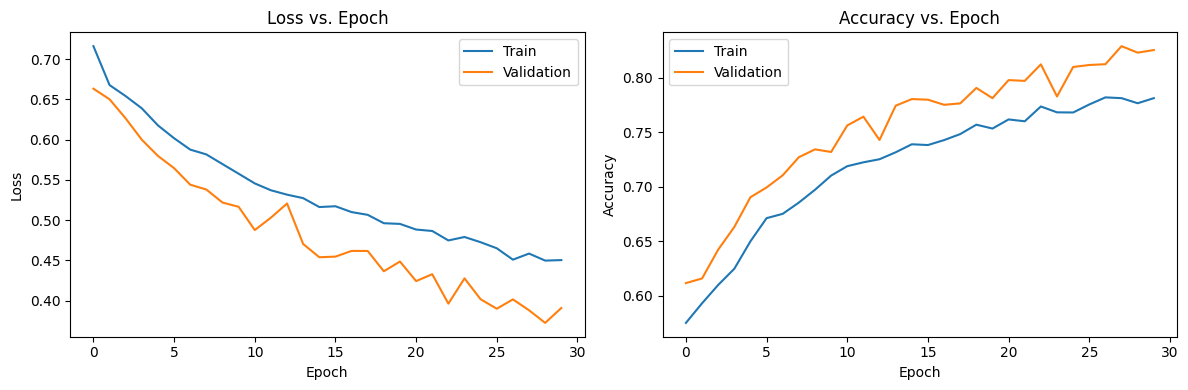

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss vs. Epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy vs. Epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


## 10. Test-set evaluation

Test accuracy: 0.8231

              precision    recall  f1-score   support

  depressive       0.80      0.82      0.81      3229
     natural       0.85      0.82      0.83      3838

    accuracy                           0.82      7067
   macro avg       0.82      0.82      0.82      7067
weighted avg       0.82      0.82      0.82      7067



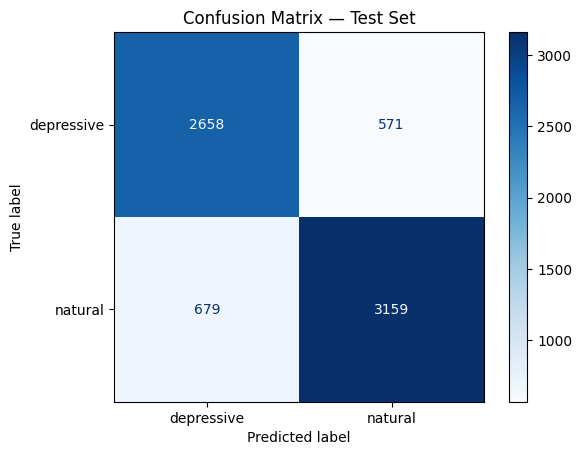

In [17]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        preds = logits.argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [18]:
# Save the trained model for later reuse (e.g. in the upload-and-predict section)
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_ds.class_to_idx,
    "mean": mean.item(),
    "std": std.item(),
}, "emotion_cnn.pt")
print("Saved model to emotion_cnn.pt")


Saved model to emotion_cnn.pt


## 11. Upload your own image and get a prediction

This cell shows an `ipywidgets` file-upload button. Pick any face photo (or any image —
it will be converted to grayscale and resized to 48×48 to match training). It runs the same
preprocessing pipeline used for the test set, then a forward pass, and displays the predicted
class with its confidence.

If `ipywidgets` widgets don't render in your environment (e.g. plain Jupyter without the
widget extension), use the fallback cell right after it, which reads an image from a file path
instead.

In [20]:
!pip install ipywidgets --quiet
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

infer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean.item()], std=[std.item()]),
])

def predict_image(pil_img, show=True):
    model.eval()
    tensor = infer_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())
    pred_class = CLASS_NAMES[pred_idx]
    if show:
        plt.figure(figsize=(3, 3))
        plt.imshow(pil_img.convert("L"), cmap="gray")
        plt.axis("off")
        plt.title(f"Predicted: {pred_class} ({probs[pred_idx]*100:.1f}%)")
        plt.show()
        print("Class probabilities:")
        for cls, p in zip(CLASS_NAMES, probs):
            print(f"  {cls:12s}: {p*100:5.1f}%")
        print("\nNote: this is an emotion-image classification demo, not a clinical")
        print("depression assessment. Please do not use it to interpret real people's")
        print("mental health.")
    return pred_class, probs

uploader = widgets.FileUpload(accept="image/*", multiple=False)
out = widgets.Output()

def on_upload_change(change):
    with out:
        clear_output()
        for name, file_info in uploader.value.items() if isinstance(uploader.value, dict) else [(f["name"], f) for f in uploader.value]:
            content = file_info["content"]
            pil_img = Image.open(io.BytesIO(content))
            predict_image(pil_img)

uploader.observe(on_upload_change, names="value")
display(widgets.VBox([widgets.Label("Upload a face image:"), uploader, out]))


### Fallback: predict from a file path (no widgets needed)

Use this if the interactive uploader above doesn't render in your notebook environment.

In [ ]:
# Example usage:
# from PIL import Image
# img = Image.open("/path/to/your/image.jpg")
# predict_image(img)


## 12. Observations & limitations (fill in after your own run)

- **Accuracy achieved**: record train / validation / test accuracy from your run here.
- **Where the model struggles**: check the confusion matrix — is one class systematically
  confused for the other? Small, near-symmetric grayscale faces at 48×48 lose a lot of the
  fine detail (e.g. eye/mouth micro-expressions) that a higher-resolution image would keep.
- **Class balance**: check whether `Depressive` and `Neutral` have similar counts in
  Train/Validation/Test — imbalance inflates accuracy while hurting recall on the minority
  class.
- **Overfitting check**: if train accuracy climbs much higher than validation accuracy,
  increase dropout, add more augmentation, or reduce model capacity.
- **Scope reminder**: relabeled facial-expression data is not a validated clinical signal for
  depression. This notebook is a supervised image-classification exercise, useful for learning
  CNNs end-to-end — it is not a diagnostic or screening tool, and its output should never be
  presented to end users as a mental-health assessment.
